## Model loading 

In [3]:
from transformers import Wav2Vec2Processor,Wav2Vec2ForCTC
from datasets import load_from_disk
import pandas as pd
import torch 

path = '/home/evan1923/projects/Model/cV13_ipav2_tonev1_new/fine_tune/best'
processor = Wav2Vec2Processor.from_pretrained(path)
model = Wav2Vec2ForCTC.from_pretrained(path)

date_size = 2500
choice = 'IpaAndTone' 
is_decouple = True
mapping_version = "v1"   # "v1" or "v2"

/home/evan1923/miniconda3/envs/thesisA/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1) Load the datasets and Parameters Settings

In [7]:
from datasets import load_from_disk, concatenate_datasets
import pandas as pd

def build_vowel_consonant_sets(attribute_mapping):
    vowel_set, consonant_set = set(), set()
    for i in range(len(attribute_mapping)):
        row = attribute_mapping.iloc[i]
        ph = str(row["Phoneme_ipaDragon"]).strip()
        if int(row["vowel"]) == 1:
            vowel_set.add(ph)
        else:
            consonant_set.add(ph)
    return vowel_set, consonant_set

data_path = '/home/evan1923/projects/mandarin_p2a_model/datasets/latic_l2_v2'

## Initial settings   ###  Importantant                         STEP 1)
file_path = '/home/evan1923/projects/mandarin_p2a_model/data/Mandarin_List_attr_IPAwithTone_V3_ToneV1.txt'   

# Load the attribute mapping file                               STEP 2)
csv_file_path = '/home/evan1923/projects/mandarin_p2a_model/data/IPAwithTone_p2attr_V3_noDiph_ToneV1.csv'   
attribute_mapping = pd.read_csv(csv_file_path)
vowel_set, consonant_set = build_vowel_consonant_sets(attribute_mapping)

#### !!!!! VERY IMPORTANT                                       STEP 3)
which_type = 'transcript_IPAwithTone_actual'            # This is from the datasets itself !!!
which_sentence = 'sentence_speaker_said'                # This is from the datasets itself !!!
suppose_sentence = 'transcript_IPAwithTone_suppose'

### 2) Function settings

In [8]:
import re
# Filter the Latic Dataset if the number is there

SENTENCE_COLS = [
    "sentence_speaker_said",
    "sentence_supposed_said"
]
_digit_re = re.compile(r"\d")
def no_digit_sentence(example):
    for col in SENTENCE_COLS:
        s = example.get(col, "")
        if s and _digit_re.search(s):
            return False   # 含数字 → 丢弃
    return True

data = load_from_disk(data_path)
data = concatenate_datasets([
    data["train"],
    data["validation"],
    data["test"]
])
data = data.select(range(date_size)) 

data_filtered = data.filter(no_digit_sentence)
print(f"Before: {len(data)}")
print(f"After : {len(data_filtered)}")
data = data_filtered

## Step 1
def load_attribute_list(file_path):
    try:
        with open(file_path) as f:
            list_att = f.read().splitlines()
            return list_att
    except FileNotFoundError:
        raise FileNotFoundError(f"The list of attribute file {file_path} is not found")
             
list_att = load_attribute_list(file_path)

## Step 2 
def create_binary_groups(list_att):
    groups = []
    for att in list_att:
        binary_att = [f'p_{att}', f'n_{att}']  # Each attribute could be +ve or -ve
        groups.append(binary_att)
    return groups

groups = create_binary_groups(list_att)

## Step 3
def get_att_group_indx_map(bTraining=True):
    #Get group ids dictionary
    group_ids = [sorted(processor.tokenizer.convert_tokens_to_ids(group)) for group in groups]
    if bTraining:
        group_ids = [dict([(x[1],x[0]+1) for x in list(enumerate(g))]) for g in group_ids]
    else:
        group_ids = [dict([(x[0]+1,x[1]) for x in list(enumerate(g))]) for g in group_ids]
    return group_ids

group_ids = get_att_group_indx_map(bTraining=False)

## Step 4) Decouple if needed
if choice == 'IpaAndTone':
    decouple_diph_file = '/home/evan1923/projects/mandarin_p2a_model/data/Diphthongs_Mandarin_withTone.csv'
else:
    decouple_diph_file = '/home/evan1923/projects/mandarin_p2a_model/data/Diphthongs_Mandarin.csv'

def merge_separate_tone(phones: list[str]) -> list[str]:

    if len(phones) >= 2 and phones[-1].isdigit():
        return phones[:-2] + [phones[-2] + phones[-1]]
    return phones

def load_diph_map(path: str):
    diph_map = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = [p.strip() for p in line.split(",") if p.strip() != ""]
            key = parts[0]
            vals = parts[1:]
            diph_map[key] = vals  # list of phones
    return diph_map

# 你原来的文件路径逻辑保持不变
diphthongs_to_monophthongs_map = load_diph_map(decouple_diph_file)
IDX_RE = re.compile(r"^(.*?)(\d+)$")  # 匹配末尾数字，如 iɑʊ4 / wa2 / ai12

def decouple_token(tok: str):
    m = IDX_RE.match(tok)
    if m:
        base, idx = m.group(1), m.group(2)
        if base in diphthongs_to_monophthongs_map:
            phones = diphthongs_to_monophthongs_map[base]

            # ⭐ NEW: 处理 CSV 里 tone 是独立字段的情况
            phones = merge_separate_tone(phones)

            return phones[:-1] + [phones[-1] + idx]
        return [tok]

    if tok in diphthongs_to_monophthongs_map:
        phones = diphthongs_to_monophthongs_map[tok]
        return merge_separate_tone(phones)

    return [tok]

def decouple_sentence(x):
    if isinstance(x, str):
        toks = x.split()
    else:
        toks = x  # assume list-like of tokens

    out = []
    for t in toks:
        out.extend(decouple_token(t))
    return out


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Filter: 100%|██████████| 2500/2500 [00:05<00:00, 470.25 examples/s]

Before: 2500
After : 2492


## 3) Parameters, mode, file pre settings

In [10]:
from typing import List, Dict, Optional, Tuple
from collections import Counter
import torch

# =========================
# 0) Settings
tone_collapse_strategy = "majority"  # "majority" | "first" | "last"
TONE_SET_V1 = {"tone-1", "tone-2", "tone-3", "tone-4"}
TONE_PITCH_TARGETS = {
    1: {"start": 5, "mid": 5, "end": 5},  # T1 High
    2: {"start": 3, "mid": 4, "end": 5},  # T2 Rising
    3: {"start": 2, "mid": 1, "end": 4},  # T3 Dipping
    4: {"start": 5, "mid": 3, "end": 1},  # T4 Falling
}

# =========================
# 1) Utility
def transpose_matrix(matrix: List[List[str]]) -> List[Tuple[str, ...]]:
    # [num_groups][T] -> [T][num_groups]
    return list(zip(*matrix))

def choose_one(items: List[str], strategy: str) -> str:
    if strategy == "majority":
        return Counter(items).most_common(1)[0][0]
    if strategy == "first":
        return items[0]
    if strategy == "last":
        return items[-1]
    raise ValueError("strategy must be one of: majority, first, last")

def collapse_set_to_one(token_seq: List[str], token_set: set, strategy: str = "majority") -> List[str]:
    picks = [t for t in token_seq if t in token_set]
    if not picks:
        return token_seq
    chosen = choose_one(picks, strategy)
    return [chosen if t in token_set else t for t in token_seq]

def collapse_prefix_to_one(token_seq: List[str], prefix: str, strategy: str = "majority") -> List[str]:
    picks = [t for t in token_seq if t.startswith(prefix)]
    if not picks:
        return token_seq
    chosen = choose_one(picks, strategy)
    return [chosen if t.startswith(prefix) else t for t in token_seq]

def find_group_index_by_any_key(group_ids: List[dict], key_pred) -> Optional[int]:
    for gi, g in enumerate(group_ids):
        if not isinstance(g, dict):
            continue
        keys = list(g.keys())
        if any(key_pred(k) for k in keys):
            return gi
    return None

def find_v1_tone_group_index(group_ids: List[dict]) -> Optional[int]:
    return find_group_index_by_any_key(group_ids, lambda k: k in TONE_SET_V1)

def find_v2_pitch_group_indices(group_ids: List[dict]) -> Dict[str, Optional[int]]:
    # We detect groups by whether they contain tokens like "start-5", "mid-3", "end-1"
    return {
        "start": find_group_index_by_any_key(group_ids, lambda k: isinstance(k, str) and k.startswith("start-")),
        "mid":   find_group_index_by_any_key(group_ids, lambda k: isinstance(k, str) and k.startswith("mid-")),
        "end":   find_group_index_by_any_key(group_ids, lambda k: isinstance(k, str) and k.startswith("end-")),
    }

def token_to_pitch_value(tok: str, prefix: str) -> Optional[int]:
    # tok like "start-5" -> 5
    if not tok.startswith(prefix):
        return None
    try:
        return int(tok.split("-")[1])
    except Exception:
        return None

def v2_triplet_to_tone(start_tok: str, mid_tok: str, end_tok: str) -> Optional[str]:
    sv = token_to_pitch_value(start_tok, "start-")
    mv = token_to_pitch_value(mid_tok, "mid-")
    ev = token_to_pitch_value(end_tok, "end-")
    if sv is None or mv is None or ev is None:
        return None

    for tone, d in TONE_PITCH_TARGETS.items():
        if d["start"] == sv and d["mid"] == mv and d["end"] == ev:
            return f"tone-{tone}"
    return None

def decode_group_from_logits(
    logits: torch.Tensor,          # [1, T, V]
    group_dict: dict,              # token->vocab_id (as in your group_ids[i])
    processor
) -> List[str]:
    V = logits.size(-1)

    # always include 0 (blank / pad) like your code
    allowed_vocab_ids = [0] + list(group_dict.values())
    mask = torch.zeros(V, dtype=torch.bool)
    mask[allowed_vocab_ids] = True

    logits_g = logits[:, :, mask]              # [1, T, Vg]
    pred_pos = torch.argmax(logits_g, dim=-1)  # [1, T] positions in Vg

    # map pos-in-Vg -> vocab_id
    pos2vocab = torch.tensor(allowed_vocab_ids, dtype=torch.long)  # [Vg]
    pred_vocab = pos2vocab[pred_pos.cpu()]                         # [1, T] vocab ids

    # decode -> tokens
    text = processor.batch_decode(pred_vocab, spaces_between_special_tokens=True)[0]
    text = text.replace("p_", "")
    toks = text.split()
    return toks

# =========================
# 2) Decide which groups to collapse
# =========================
tone_group_idx_v1 = None
pitch_group_idx_v2 = {"start": None, "mid": None, "end": None}

if mapping_version == "v1":
    tone_group_idx_v1 = find_v1_tone_group_index(group_ids)
elif mapping_version == "v2":
    pitch_group_idx_v2 = find_v2_pitch_group_indices(group_ids)
else:
    raise ValueError("mapping_version must be 'v1' or 'v2'")

# =========================
# 3) Main decoding loop
# =========================
prediction = []
actual_sentence = []
supposed_sentence = []
Mandarin_sentence = []

for item in data:
    audio_array = item["audio"]["array"]
    sampling_rate = item["audio"]["sampling_rate"]
    inputs = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt", padding=True)

    with torch.no_grad():
        logits = model(inputs.input_values).logits  # [1, T, V]

    item_output: List[List[str]] = []

    for i in range(len(group_ids)):
        toks = decode_group_from_logits(logits, group_ids[i], processor)

        # ---- collapse logic depends on mapping version ----
        if mapping_version == "v1":
            if tone_group_idx_v1 is not None and i == tone_group_idx_v1:
                toks = collapse_set_to_one(toks, TONE_SET_V1, strategy=tone_collapse_strategy)

        elif mapping_version == "v2":
            # collapse each pitch segment group independently
            if pitch_group_idx_v2["start"] is not None and i == pitch_group_idx_v2["start"]:
                toks = collapse_prefix_to_one(toks, "start-", strategy=tone_collapse_strategy)
            if pitch_group_idx_v2["mid"] is not None and i == pitch_group_idx_v2["mid"]:
                toks = collapse_prefix_to_one(toks, "mid-", strategy=tone_collapse_strategy)
            if pitch_group_idx_v2["end"] is not None and i == pitch_group_idx_v2["end"]:
                toks = collapse_prefix_to_one(toks, "end-", strategy=tone_collapse_strategy)

        item_output.append(toks)

    # transpose: [num_groups][T] -> [T][num_groups]
    transposed_item_output = transpose_matrix(item_output)
    prediction.append(transposed_item_output)

    actual_sentence.append(item[which_type].split())
    supposed_sentence.append(item[suppose_sentence])
    Mandarin_sentence.append(item[which_sentence])


if is_decouple:
    actual_sentence = [decouple_sentence(item) for item in actual_sentence]
    supposed_sentence = [decouple_sentence(item) for item in supposed_sentence]
    print(actual_sentence[3])
    print(supposed_sentence[3])

['tʰ', 'a1', 't', 'ɤ', 'ʐ', 'ə2', 'n', 'l', 'ɤ', 'i4', 'y', 'ɔ', 'ʊ2', 'l', 'a', 'i2', 'i', 'ɤ3', 'ʈʂʰ', 'u1', 'p', 'a3', 'n', 'l', 'ɤ', 'i4', 'n', 'i', 'ɤ2', 'n', 'l', 'ɤ']
['tʰ', 'a1', 't', 'ɤ', 'ʐ', 'ə2', 'n', 'l', 'ɤ', 'i4', 'y', 'ɔ', 'ʊ2', 'l', 'a', 'i2', 'i', 'ɤ3', 'ʈʂʰ', 'u1', 'p', 'a3', 'n', 'l', 'ɤ', 'i4', 'n', 'i', 'ɤ2', 'n', 'l', 'ɤ']


# Pronunication Feedback Early design

In [11]:
 
from collections import defaultdict
import pandas as pd
from Levenshtein import editops
 
# -------------------------
# 1) Build mapping: phoneme -> positive-attrs
# -------------------------
def build_phoneme2posattrs(attribute_mapping: pd.DataFrame,
                           phoneme_col: str = "Phoneme_ipaDragon"):
    attr_cols = [c for c in attribute_mapping.columns
                if c != phoneme_col and c not in EXCLUDE_ATTRS]
    phoneme2pos = {}
    for _, row in attribute_mapping.iterrows():
        ph = str(row[phoneme_col]).strip()
        pos = set()
        for a in attr_cols:
            try:
                if int(row[a]) == 1:
                    pos.add(a)
            except Exception:
                pass
        phoneme2pos[ph] = pos
    return phoneme2pos, attr_cols
 
# -------------------------
# 2) pred: frame(49 tokens) -> dict[attr]=bool_pos
# -------------------------
def frame_to_attr_bool(frame_tokens):
    d = {}
    for tok in frame_tokens:
        tok = str(tok)
        if tok.startswith("n_"):
            d[tok[2:]] = False
        else:
            d[tok] = True
    return d
 
def collapse_attr_vectors(pred_vectors_T):
    collapsed = []
    prev = None
    for frame in pred_vectors_T:
        cur = frame_to_attr_bool(frame)
        if prev is None or cur != prev:
            collapsed.append(cur)
            prev = cur
    return collapsed
 
def pred_attr_seq_from_collapsed(collapsed_vecs, att):
    # sequence of '+att' or '-att'
    return [("+"+att) if vec.get(att, False) else ("-"+att) for vec in collapsed_vecs]
 
import ast
def parse_phoneme_seq(x):
    # 1) already list
    if isinstance(x, list):
        return [str(t).strip() for t in x]
 
    s = str(x).strip()
 
    # 2) stringified python list
    if (s.startswith("[") and s.endswith("]")):
        try:
            arr = ast.literal_eval(s)
            if isinstance(arr, list):
                return [str(t).strip() for t in arr]
        except Exception:
            pass
 
    # 3) fallback: whitespace separated
    return [t.strip() for t in s.split() if t.strip()]
# -------------------------
# 3) gold/actual phoneme seq -> '+/-att' seq
# -------------------------
def phoneme_seq_to_attr_seq(phoneme_seq, att, phoneme2pos):
    out = []
    for ph in phoneme_seq:
        ph = str(ph).strip()
        pos = phoneme2pos.get(ph, set())
        out.append("+"+att if att in pos else "-"+att)
    return out
 
# -------------------------
# 4) Levenshtein alignment (ref vs hyp)
# -------------------------
def align_with_editops(ref, hyp, hyp_gap="emp", ref_gap="del"):
    ops = editops(ref, hyp)
    aligned_ref = []
    aligned_hyp = []
    i = j = 0
    k = 0
    
    while i < len(ref) or j < len(hyp):
        if k < len(ops) and ops[k][1] == i and ops[k][2] == j:
            op, ref_i, hyp_j = ops[k]
 
            if op == "delete":
                # ref has token, hyp missing
                aligned_ref.append(ref[i])
                aligned_hyp.append(hyp_gap)
                i += 1
 
            elif op == "insert":
                # hyp has extra token
                aligned_ref.append(ref_gap)
                aligned_hyp.append(hyp[j])
                j += 1
 
            elif op == "replace":
                aligned_ref.append(ref[i])
                aligned_hyp.append(hyp[j])
                i += 1
                j += 1
 
            k += 1
        else:
            # match
            if i < len(ref) and j < len(hyp):
                aligned_ref.append(ref[i])
                aligned_hyp.append(hyp[j])
                i += 1
                j += 1
            elif i < len(ref):
                aligned_ref.append(ref[i])
                aligned_hyp.append(hyp_gap)
                i += 1
            else:
                aligned_ref.append(ref_gap)
                aligned_hyp.append(hyp[j])
                j += 1
 
    return aligned_ref, aligned_hyp
 
def merge_alignments(g_p, p, g_a, a, gold_gap="del", hyp_gap="emp"):
    i = j = 0
    g_common, p_common, a_common = [], [], []
 
    while i < len(g_p) or j < len(g_a):
        # Take current tokens or None if exhausted
        tp = g_p[i] if i < len(g_p) else None
        ta = g_a[j] if j < len(g_a) else None
 
        # Case 1: both exist and exactly same gold token (including "del")
        if tp is not None and ta is not None and tp == ta:
            g_common.append(tp)
            p_common.append(p[i])
            a_common.append(a[j])
            i += 1
            j += 1
            continue
 
        if tp == gold_gap and (ta != gold_gap):
            g_common.append(gold_gap)
            p_common.append(p[i])      # keep pred's extra token aligned here
            a_common.append(hyp_gap)   # actual has nothing here
            i += 1
            continue
 
        if ta == gold_gap and (tp != gold_gap):
            g_common.append(gold_gap)
            p_common.append(hyp_gap)   # pred has nothing here
            a_common.append(a[j])      # keep actual's extra token aligned here
            j += 1
            continue
 
        if tp is None:
            g_common.append(ta)
            p_common.append(hyp_gap)
            a_common.append(a[j])
            j += 1
        elif ta is None:
            g_common.append(tp)
            p_common.append(p[i])
            a_common.append(hyp_gap)
            i += 1
        else:
            # consume both as-is (rare); you can also choose to insert gaps instead
            g_common.append(tp)
            p_common.append(p[i])
            a_common.append(a[j])
            i += 1
            j += 1
 
    assert len(g_common) == len(p_common) == len(a_common), (len(g_common), len(p_common), len(a_common))
    return g_common, a_common, p_common
 
def align_pred_act_to_gold(supposed_tok, pred_tok, act_tok):
    # Align gold vs pred
    g_p, p_al = align_with_editops(supposed_tok, pred_tok, hyp_gap="emp", ref_gap="del")
    # Align gold vs actual
    g_a, a_al = align_with_editops(supposed_tok, act_tok, hyp_gap="emp", ref_gap="del")
 
    # Merge to one common gold spine
    g, a, p = merge_alignments(g_p, p_al, g_a, a_al, gold_gap="del", hyp_gap="emp")
    return g, a, p
# -------------------------
# 5) Shahin-style counts + rates (per attribute)
# -------------------------
 
def add_counts(dst, src):
    for k in ["TA","TR","FA","FR","CD","DE"]:
        dst[k] += src.get(k, 0)
 
 
def finalize_from_counts(c):
    TA, TR, FA, FR, CD, DE = c["TA"], c["TR"], c["FA"], c["FR"], c["CD"], c["DE"]
    FAR = FA/(FA+TR) if (FA+TR) else 0.0
    FRR = FR/(FR+TA) if (FR+TA) else 0.0
    DER = DE/(CD+DE) if (CD+DE) else 0.0
    return FAR, FRR, DER
 
def attr_mdd_counts_and_rates_clean(gold_seq, act_seq, pred_seq, debug=False, max_print=60):
    G, A, P = align_pred_act_to_gold(gold_seq, pred_seq, act_seq)
 
    TA=TR=FA=FR=CD=DE=0
    EMPTY = ("emp", "del")
 
    for gi, ai, pi in zip(G, A, P):
        if gi.startswith("-"):
            continue
        
        # ---- your original logic ----
        if gi in EMPTY:        
            if ai == pi:
                TA += 1
                continue
            else:
                continue
 
        if ai in EMPTY:
            if pi == ai:
                TR += 1
                CD += 1
                continue
            else:
                if pi == gi:
                    TA += 1
                else:
                    TR += 1
                    if pi in EMPTY:
                        CD += 1
                    else:
                        DE += 1
                continue
 
        is_correct = (ai == gi)
        if is_correct:
            if pi == gi:
                TA += 1
            else:
                FR += 1
        else:
            if pi == gi:
                FA += 1
            else:
                TR += 1
                if pi == ai:
                    CD += 1
                else:
                    DE += 1
 
    FAR = FA/(FA+TR) if (FA+TR) else 0.0
    FRR = FR/(FR+TA) if (FR+TA) else 0.0
    DER = DE/(CD+DE) if (CD+DE) else 0.0
    return dict(TA=TA, TR=TR, FA=FA, FR=FR, CD=CD, DE=DE, FAR=FAR, FRR=FRR, DER=DER)
 
 
def gold_has_positive(gold_seq, att):
    pos_tok = "+" + att
    return any(t == pos_tok for t in gold_seq)
 
def eval_attr_level_pipeline(prediction, supposed_sentence, actual_sentence,
                             attribute_mapping_csv_path,
                             phoneme_col="Phoneme_ipaDragon",
                             verbose=False):
    attribute_mapping = pd.read_csv(attribute_mapping_csv_path)
    phoneme2pos, attr_names = build_phoneme2posattrs(attribute_mapping, phoneme_col=phoneme_col)
 
    totals = {att: defaultdict(int) for att in attr_names}
 
    total_gold_tokens = 0
    used_utts = 0
    skipped_utts = 0
    skip_ph = 0
 
 
    for u in range(len(prediction)):
        # gold/actual phoneme seq
        gold_ph = str(supposed_sentence[u]).split()
        act_ph  = actual_sentence[u] if isinstance(actual_sentence[u], list) else str(actual_sentence[u]).split()
 
        gold_ph = parse_phoneme_seq(supposed_sentence[u])
        act_ph  = parse_phoneme_seq(actual_sentence[u])
 
        pred_T = prediction[u]
        if pred_T is None or len(pred_T) == 0:
            skipped_utts += 1
            continue
 
        pred_U = collapse_attr_vectors(pred_T)
 
        for att in attr_names:
            pred_seq = pred_attr_seq_from_collapsed(pred_U, att)
            gold_seq = phoneme_seq_to_attr_seq(gold_ph, att, phoneme2pos)
            act_seq  = phoneme_seq_to_attr_seq(act_ph,  att, phoneme2pos)
    
            # # ✅ NEW: if gold never has +att in this utterance, skip this att for this utt
            # if not gold_has_positive(gold_seq, att):
            #     skip_ph += 1
            #     continue
 
            r = attr_mdd_counts_and_rates_clean(gold_seq, act_seq, pred_seq)
            add_counts(totals[att], r)
 
        # ✅ IMPORTANT: count filtered gold tokens
        total_gold_tokens += len(gold_ph)
        used_utts += 1
 
        if u == 2499:
            break
        if verbose and u < 3:
            print(f"[utt {u}] gold_len={len(gold_ph)} predU_len={len(pred_U)}")
 
    results = []
    for idx, att in enumerate(attr_names):
        c = totals[att]
        FAR, FRR, DER = finalize_from_counts(c)
        results.append({
            "idx": idx,
            "attr": att,
            "TA": c["TA"], "TR": c["TR"], "FA": c["FA"], "FR": c["FR"],
            "CD": c["CD"], "DE": c["DE"],
            "FAR%": FAR*100, "FRR%": FRR*100, "DER%": DER*100
        })
 
    total_attr_decisions = total_gold_tokens * len(attr_names)
    print(skip_ph/41)
    return results, dict(
        used_utts=used_utts,
        skipped_utts=skipped_utts,
        total_gold_tokens=total_gold_tokens,
        num_attrs=len(attr_names),
        total_attr_decisions=total_attr_decisions
    )

# -------------------------
# 7) Pretty print (rank by FAR)
# -------------------------
def print_attr_report(results, meta, sort_by="FAR%"):
    print(f"Used utts: {meta['used_utts']} | Skipped utts: {meta['skipped_utts']}")
    print("\n" + "="*100)
    print("FINAL ATTRIBUTE-LEVEL MDD EVALUATION")
    print("="*100)
 
    results_sorted = sorted(results, key=lambda x: x[sort_by])
 
    for r in results_sorted:
        print(f"{r['idx']:02d} | {r['attr']:<16} | "
              f"TA={r['TA']:6d} TR={r['TR']:6d}(CD={r['CD']:6d},DE={r['DE']:6d}) "
              f"FA={r['FA']:6d} FR={r['FR']:6d} | "
              f"FAR={r['FAR%']:6.2f}% FRR={r['FRR%']:6.2f}% DER={r['DER%']:6.2f}%")
        
EXCLUDE_ATTRS = {
    "Phoneme_pinyin",
    "Language",
    "earlySound",
    "backSound",
    "midSound"
}
 

### Attibute level

In [12]:
results, meta = eval_attr_level_pipeline(
    prediction=prediction,
    supposed_sentence=supposed_sentence,
    actual_sentence=actual_sentence,
    attribute_mapping_csv_path=csv_file_path,
    phoneme_col="Phoneme_ipaDragon",
    verbose=True
)

print_attr_report(results, meta, sort_by="FAR%")

[utt 0] gold_len=16 predU_len=17
[utt 1] gold_len=45 predU_len=46
[utt 2] gold_len=44 predU_len=42
0.0
Used utts: 2491 | Skipped utts: 1

FINAL ATTRIBUTE-LEVEL MDD EVALUATION
23 | Mid              | TA=  2240 TR=    26(CD=    22,DE=     4) FA=     0 FR=   464 | FAR=  0.00% FRR= 17.16% DER= 15.38%
24 | Open-Mid         | TA=  1333 TR=    15(CD=    11,DE=     4) FA=     0 FR=   157 | FAR=  0.00% FRR= 10.54% DER= 26.67%
28 | Middle           | TA=  2233 TR=    26(CD=    22,DE=     4) FA=     0 FR=   468 | FAR=  0.00% FRR= 17.33% DER= 15.38%
29 | Low-Mid          | TA=  1341 TR=    15(CD=    10,DE=     5) FA=     0 FR=   156 | FAR=  0.00% FRR= 10.42% DER= 33.33%
34 | labial-palatal   | TA=  1092 TR=     0(CD=     0,DE=     0) FA=     0 FR=     0 | FAR=  0.00% FRR=  0.00% DER=  0.00%
02 | Voiceless        | TA= 23095 TR=   115(CD=   108,DE=     7) FA=     2 FR=   392 | FAR=  1.71% FRR=  1.67% DER=  6.09%
35 | vowel            | TA= 41603 TR=   188(CD=   178,DE=    10) FA=     4 FR=  1055 | 

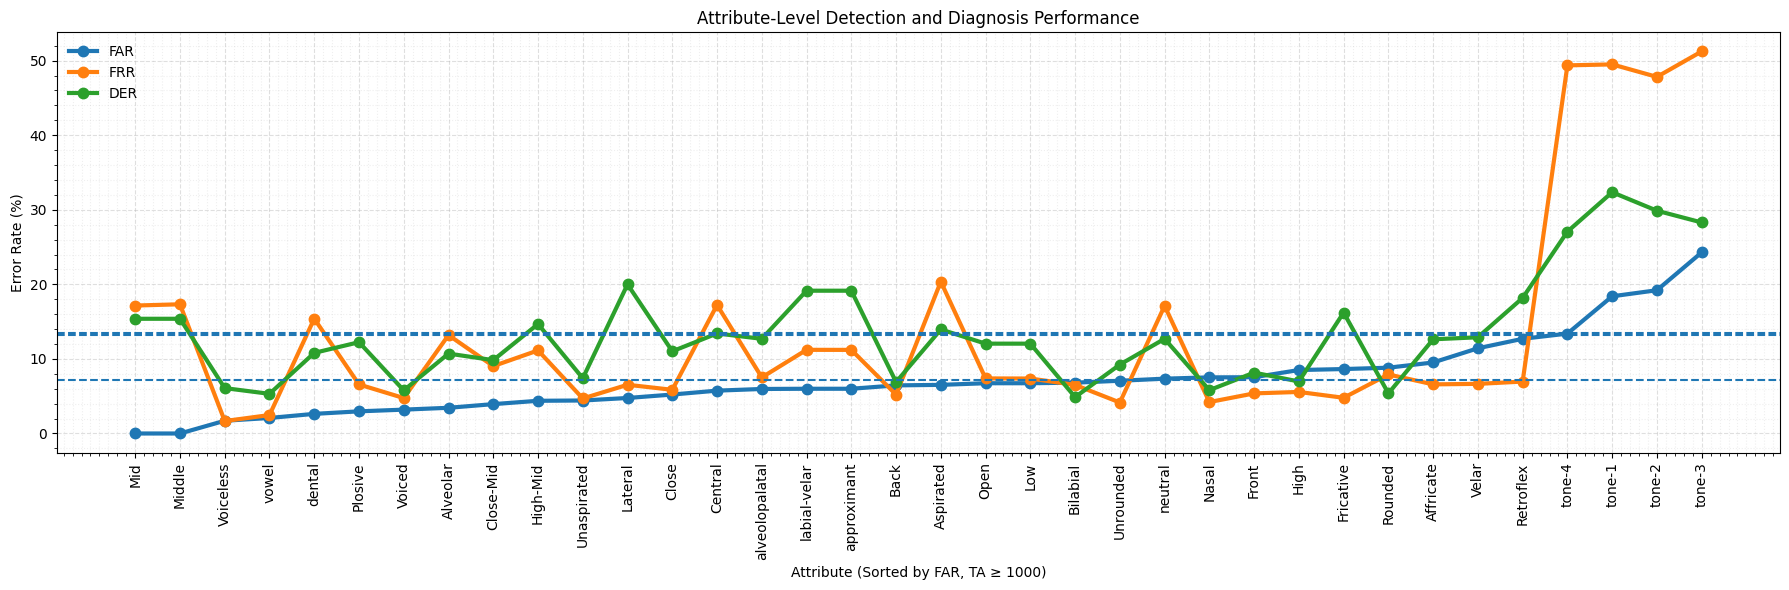

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
LINEWIDTH = 3
MARKSIZE = 2.5 * LINEWIDTH
 
df = pd.DataFrame(results)
 
# ✅ 1️⃣ 过滤 TA < 1000
df = df[df["TA"] >= 2000].copy()
 
# 如果过滤后为空，防止报错
if len(df) == 0:
    print("No attributes with TA >= 1000")
else:
    # ✅ 2️⃣ 排序
    df = df.sort_values("FAR%").reset_index(drop=True)
 
    # ✅ 3️⃣ 重新计算 mean（基于过滤后的）
    far_mean = df["FAR%"].mean()
    frr_mean = df["FRR%"].mean()
    der_mean = df["DER%"].mean()
 
    plt.figure(figsize=(18,6))
 
    # ---- 曲线 ----
    plt.plot(df["FAR%"], linewidth=LINEWIDTH, marker='o',
             markersize=MARKSIZE, label="FAR")
    plt.plot(df["FRR%"], linewidth=LINEWIDTH, marker='o',
             markersize=MARKSIZE, label="FRR")
    plt.plot(df["DER%"], linewidth=LINEWIDTH, marker='o',
             markersize=MARKSIZE, label="DER")
 
    # ---- Mean 横线 ----
    plt.axhline(far_mean, linestyle="--", linewidth=1.5)
    plt.axhline(frr_mean, linestyle="--", linewidth=1.5)
    plt.axhline(der_mean, linestyle="--", linewidth=1.5)
 
    # ---- X轴 ----
    plt.xticks(np.arange(len(df)), df["attr"], rotation=90)
    plt.ylabel("Error Rate (%)")
    plt.xlabel("Attribute (Sorted by FAR, TA ≥ 1000)")
    plt.title("Attribute-Level Detection and Diagnosis Performance")
 
    # ---- Grid ----
    plt.grid(True, which="major", linestyle="--", alpha=0.4)
    plt.minorticks_on()
    plt.grid(True, which="minor", linestyle=":", alpha=0.2)
 
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
 
 

In [14]:
# -------------------------
# Attribute groups
# -------------------------
 
consonant_attrs = [
    "Unaspirated", "Aspirated", "Voiceless", "Voiced",
    "Plosive", "Bilabial", "Nasal", "dentolabial",
    "Fricative", "dental", "Affricate", "Alveolar",
    "Lateral", "Retroflex", "alveolopalatal",
    "Velar", "pproximant", "labial-velar", "labial-palatal"
]
 
vowel_attrs = [
    "Unrounded", "Rounded",
    "Front", "Central", "Back",
    "Close", "Close-Mid", "Mid",
    "Open-Mid", "Open",
    "High", "High-Mid", "Middle",
    "Low-Mid", "Low",
    "neutral", "approximant", "vowel"
]
 
tone_attrs = [
    "start-5", "start-3", "start-2",
    "mid-1", "mid-3", "mid-4", "mid-5",
    "end-5", "end-4", "end-1",
    "tone-1", "tone-2", "tone-3", "tone-4"
]
 
def print_group_average(df, group_name, attr_list):
    group_df = df[df["attr"].isin(attr_list)]
    
    far_mean = group_df["FAR%"].mean()
    frr_mean = group_df["FRR%"].mean()
    der_mean = group_df["DER%"].mean()
    
    print(f"\n===== {group_name} =====")
    print(f"Attributes counted: {len(group_df)}")
    print(f"Average FAR : {far_mean:.2f}%")
    print(f"Average FRR : {frr_mean:.2f}%")
    print(f"Average DER : {der_mean:.2f}%")
 
print_group_average(df, "Consonant Attributes", consonant_attrs)
print_group_average(df, "Vowel Attributes", vowel_attrs)
print_group_average(df, "Tone Attributes", tone_attrs)
 
# -------------------------
# Tone summary (CAT/PT)
# -------------------------
 
TONE_PITCH_TARGETS = {
    1: {"start": 5, "mid": 5, "end": 5},  # tone-1
    2: {"start": 3, "mid": 4, "end": 5},  # tone-2
    3: {"start": 2, "mid": 1, "end": 4},  # tone-3
    4: {"start": 5, "mid": 3, "end": 1},  # tone-4
}
 
def _summarize_attrs(df, attrs, label):
    """Unweighted mean over attributes (each attr counted once)."""
    sub = df[df["attr"].isin(attrs)]
    missing = [a for a in attrs if a not in set(df["attr"])]
    if len(sub) == 0:
        print(f"\n===== {label} =====")
        print("No matched attributes in df.")
        if missing:
            print("Missing attrs:", missing)
        return
 
    far = sub["FAR%"].mean()
    frr = sub["FRR%"].mean()
    der = sub["DER%"].mean()
 
    print(f"\n===== {label} =====")
    print(f"Attributes counted: {len(sub)}")
    print(f"Average FAR : {far:.2f}%")
    print(f"Average FRR : {frr:.2f}%")
    print(f"Average DER : {der:.2f}%")
    if missing:
        print(f"(warning) missing {len(missing)} attrs:", missing)
 
def print_tone_summary(df, mode="PT", include_tone_token_in_pt=True):
    """
    mode:
      - "CAT": categorical tones (tone-1..4)
      - "PT" : pitch-target tones (start/mid/end-*)
    include_tone_token_in_pt:
      - if True and df contains tone-k tokens, include them in per-tone PT aggregation.
    """
    mode = mode.upper().strip()
    if mode not in {"CAT", "PT"}:
        raise ValueError("mode must be 'CAT' or 'PT'")
 
    # ---- define tone attribute pools ----
    tone_cat_attrs = [f"tone-{k}" for k in [1,2,3,4]]
 
    tone_pt_attrs = [
        "start-5", "start-3", "start-2",
        "mid-1", "mid-3", "mid-4", "mid-5",
        "end-5", "end-4", "end-1",
    ]
 
    # ---- overall summary ----
    if mode == "CAT":
        _summarize_attrs(df, tone_cat_attrs, "Tone-CAT (overall: mean over tone-1..4)")
    else:
        _summarize_attrs(df, tone_pt_attrs, "Tone-PT (overall: mean over pitch-target attrs)")
 
    # ---- per-tone summary ----
    print("\n----- Per-tone breakdown -----")
    for k in [1,2,3,4]:
        if mode == "CAT":
            # Each tone is just its categorical attribute
            attrs_k = [f"tone-{k}"]
            _summarize_attrs(df, attrs_k, f"Tone-{k} (CAT)")
        else:
            # Each tone aggregated by its pitch targets
            t = TONE_PITCH_TARGETS[k]
            attrs_k = [f"start-{t['start']}", f"mid-{t['mid']}", f"end-{t['end']}"]
 
            # optionally include tone-k token if it exists in df (some setups keep both)
            tone_tok = f"tone-{k}"
            if include_tone_token_in_pt and (tone_tok in set(df["attr"])):
                attrs_k = attrs_k + [tone_tok]
 
            _summarize_attrs(df, attrs_k, f"Tone-{k} (PT)")
 
# Usage:
print_tone_summary(df, mode="CAT")
print_tone_summary(df, mode="PT", include_tone_token_in_pt=True)
 


===== Consonant Attributes =====
Attributes counted: 16
Average FAR : 6.14%
Average FRR : 7.98%
Average DER : 11.84%

===== Vowel Attributes =====
Attributes counted: 16
Average FAR : 5.41%
Average FRR : 9.47%
Average DER : 11.10%

===== Tone Attributes =====
Attributes counted: 4
Average FAR : 18.82%
Average FRR : 49.48%
Average DER : 29.40%

===== Tone-CAT (overall: mean over tone-1..4) =====
Attributes counted: 4
Average FAR : 18.82%
Average FRR : 49.48%
Average DER : 29.40%

----- Per-tone breakdown -----

===== Tone-1 (CAT) =====
Attributes counted: 1
Average FAR : 18.40%
Average FRR : 49.50%
Average DER : 32.35%

===== Tone-2 (CAT) =====
Attributes counted: 1
Average FAR : 19.21%
Average FRR : 47.82%
Average DER : 29.88%

===== Tone-3 (CAT) =====
Attributes counted: 1
Average FAR : 24.29%
Average FRR : 51.24%
Average DER : 28.30%

===== Tone-4 (CAT) =====
Attributes counted: 1
Average FAR : 13.40%
Average FRR : 49.37%
Average DER : 27.07%

===== Tone-PT (overall: mean over pitch